> **Note:** The canonical figure for **Figure 2** (`fig_traffic_light.pdf`) is now produced by the standalone Quantlet `CO_heatmap/`. This notebook is retained because it also produces intermediate data and serves as a development reference.

# CFP_Traffic_Light

Basel Traffic Light heatmap (9 models × 24 assets) after conformal correction at α = 0.01.

**Output:** `fig_traffic_light.pdf`  
**Paper:** Pele, Bolovaneanu, Ginavar, Lessmann, Härdle (2026)  
**Q** [Conformal_Oracle](https://github.com/QuantLet/Conformal_Oracle/)

Loaded 864 rows (9 models, 24 assets, 4 alphas)


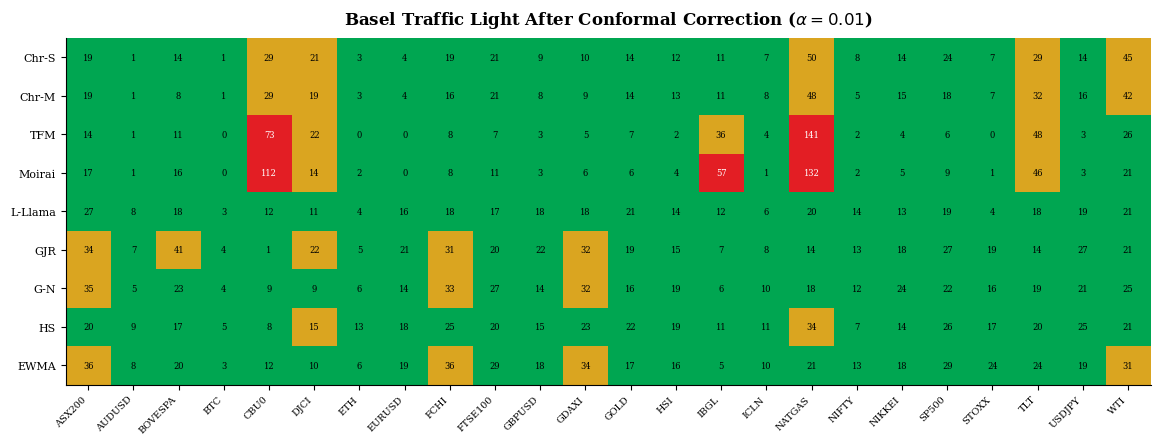

Saved fig_traffic_light.pdf


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import shutil, warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────
DATA_DIR = Path('../cfp_ijf_data')
RES_DIR  = DATA_DIR / 'paper_outputs' / 'tables'
FIG_DIR  = DATA_DIR / 'paper_outputs' / 'figures'
ROOT_FIG = Path('../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
ROOT_FIG.mkdir(parents=True, exist_ok=True)

# ── Style ─────────────────────────────────────────────
C_GRAY='#666666'; C_TEAL='#00A651'; C_RED='#E31E24'
C_BLUE='#0066CC'; C_PURPLE='#7B2FBE'
plt.rcParams.update({
    'font.family':'serif', 'axes.grid':False,
    'savefig.transparent':True, 'savefig.dpi':300,
    'axes.spines.top':False, 'axes.spines.right':False,
    'font.size':10,
})

# ── Data ───────────────────────────────────────────────────────────
df  = pd.read_csv(RES_DIR / 'all_results.csv')
d01 = df[df['alpha'] == 0.01].copy()
print(f'Loaded {len(df)} rows '
      f'({df["model"].nunique()} models, '
      f'{df["symbol"].nunique()} assets, '
      f'{df["alpha"].nunique()} alphas)')

MODEL_ORDER = ['Chronos-Small','Chronos-Mini','TimesFM-2.5',
               'Moirai-2.0','Lag-Llama',
               'GJR-GARCH','GARCH-N','Hist-Sim','EWMA']
MODEL_SHORT = ['Chr-S','Chr-M','TFM','Moirai','L-Llama',
               'GJR','G-N','HS','EWMA']
ASSETS = sorted(d01['symbol'].unique())

# ── Heatmap matrix ─────────────────────────────────────────────────
tl_map = {'Green':0, 'Yellow':1, 'Red':2}
mat = np.full((len(MODEL_ORDER), len(ASSETS)), np.nan)
for i, m in enumerate(MODEL_ORDER):
    for j, a in enumerate(ASSETS):
        row = d01[(d01['model']==m) & (d01['symbol']==a)]
        if len(row)==1:
            mat[i,j] = tl_map.get(row.iloc[0]['TL_cp'], np.nan)

cmap = ListedColormap([C_TEAL, '#DAA520', C_RED])
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.imshow(mat, cmap=cmap, vmin=0, vmax=2, aspect='auto')
ax.set_title('Basel Traffic Light After Conformal Correction ($\\alpha = 0.01$)',
             fontsize=12, fontweight='bold', pad=10)

ax.set_xticks(range(len(ASSETS)))
ax.set_xticklabels(ASSETS, fontsize=7, rotation=45, ha='right')
ax.set_yticks(range(len(MODEL_ORDER)))
ax.set_yticklabels(MODEL_SHORT, fontsize=8)

for i in range(len(MODEL_ORDER)):
    for j in range(len(ASSETS)):
        row = d01[(d01['model']==MODEL_ORDER[i]) & (d01['symbol']==ASSETS[j])]
        if len(row)==1:
            v = int(row.iloc[0]['viol_cp'])
            ax.text(j, i, str(v), ha='center', va='center',
                    fontsize=6, color='white' if mat[i,j]==2 else 'black')

# Legend removed — colors self-explanatory from cell labels

for ext in ['pdf','png']:
    fig.savefig(FIG_DIR / f'fig_traffic_light.{ext}', bbox_inches='tight')
for _ext in ['pdf','png']:
    shutil.copy(FIG_DIR/f'fig_traffic_light.{_ext}', ROOT_FIG/f'fig_traffic_light.{_ext}')
plt.show()
print('Saved fig_traffic_light.pdf')